# More Regressions

## The World Happiness Report

We will analyse those data to find relationships between the happiness score and economy, family, health, freedom, trust, perception of
corruption, generosity...

The dataset contains the following variables:

- Country : Country name
- Overall rank : Country ranking based on happiness score
- Score : Individual personal happiness rating from 0 to 10.
- GDP per capita : GDP per capita of each country in terms of purchasing power parity (PPP) (in USD)
- Social support : Individual rating that determines whether, when you have problems, your family or friends would help you. Binary responses (0 or 1).
- Healthy life expectancy : Healthy life expectancy at birth is based on data from the World Health Organization (WHO)
- Freedom to make life choices : Individual rating that determines whether you are satisfied or dissatisfied with your freedom to choose what you do with your life. Binary responses (0 or 1).
- Generosity : Generosity is the residual from the regression of the national mean of responses to the question "Have you donated money to a charity in the last month?" on GDP per capita.
- Perceptions of corruption : Average of binary responses to two GWP questions: corruption in government and corruption in business.

### I) Data exploration

We start by importing the libraries we need:
- `pandas` for data manipulation
- `matplotlib` and `seaborn` for plotting
- `statsmodels` for running regressions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula import api as smf

Open the csv `happiness_index_2019.csv`.

**Note:** The column names in the CSV contain spaces (e.g. "GDP per capita"). We replace spaces with underscores so we can use them easily in formulas later.

In [2]:
df = pd.read_csv('happiness_index_2019.csv')

# Replace spaces in column names with underscores
df.columns = df.columns.str.replace(' ', '_')

Explore the dataset using the `head()` function. This shows the first few rows so we can see what the data looks like.

In [3]:
df.head(10)

,Overall_rank,Country_or_region,Score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


Let's also check the shape and types of the data to make sure everything loaded correctly.

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (156, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall_rank                  156 non-null    int64  
 1   Country_or_region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP_per_capita                156 non-null    float64
 4   Social_support                156 non-null    float64
 5   Healthy_life_expectancy       156 non-null    float64
 6   Freedom_to_make_life_choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions_of_corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


Compute descriptive statistics using `describe()`. This gives us the mean, standard deviation, min, max, and quartiles for each numeric column.

In [5]:
df.describe()

,Overall_rank,Score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


Plot variables that may have a positive correlation with the happiness Score using scatter plots.

We expect GDP per capita and Healthy life expectancy to be positively correlated with happiness.

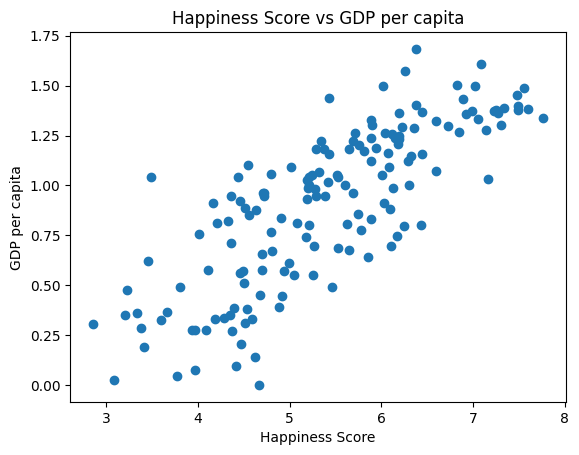

In [6]:
plt.plot(df['Score'], df['GDP_per_capita'], 'o')
plt.xlabel('Happiness Score')
plt.ylabel('GDP per capita')
plt.title('Happiness Score vs GDP per capita')
plt.show()

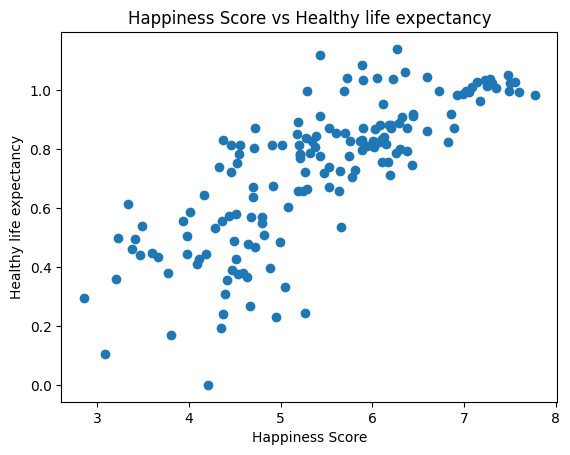

In [7]:
plt.plot(df['Score'], df['Healthy_life_expectancy'], 'o')
plt.xlabel('Happiness Score')
plt.ylabel('Healthy life expectancy')
plt.title('Happiness Score vs Healthy life expectancy')
plt.show()

Both plots show a clear positive trend: countries with higher GDP and higher life expectancy tend to be happier.

Plot the correlation matrix of the main variables using the `heatmap` function from Seaborn.

A correlation matrix shows how strongly each pair of variables is linearly related. Values close to 1 or -1 mean strong correlation; values close to 0 mean weak correlation.

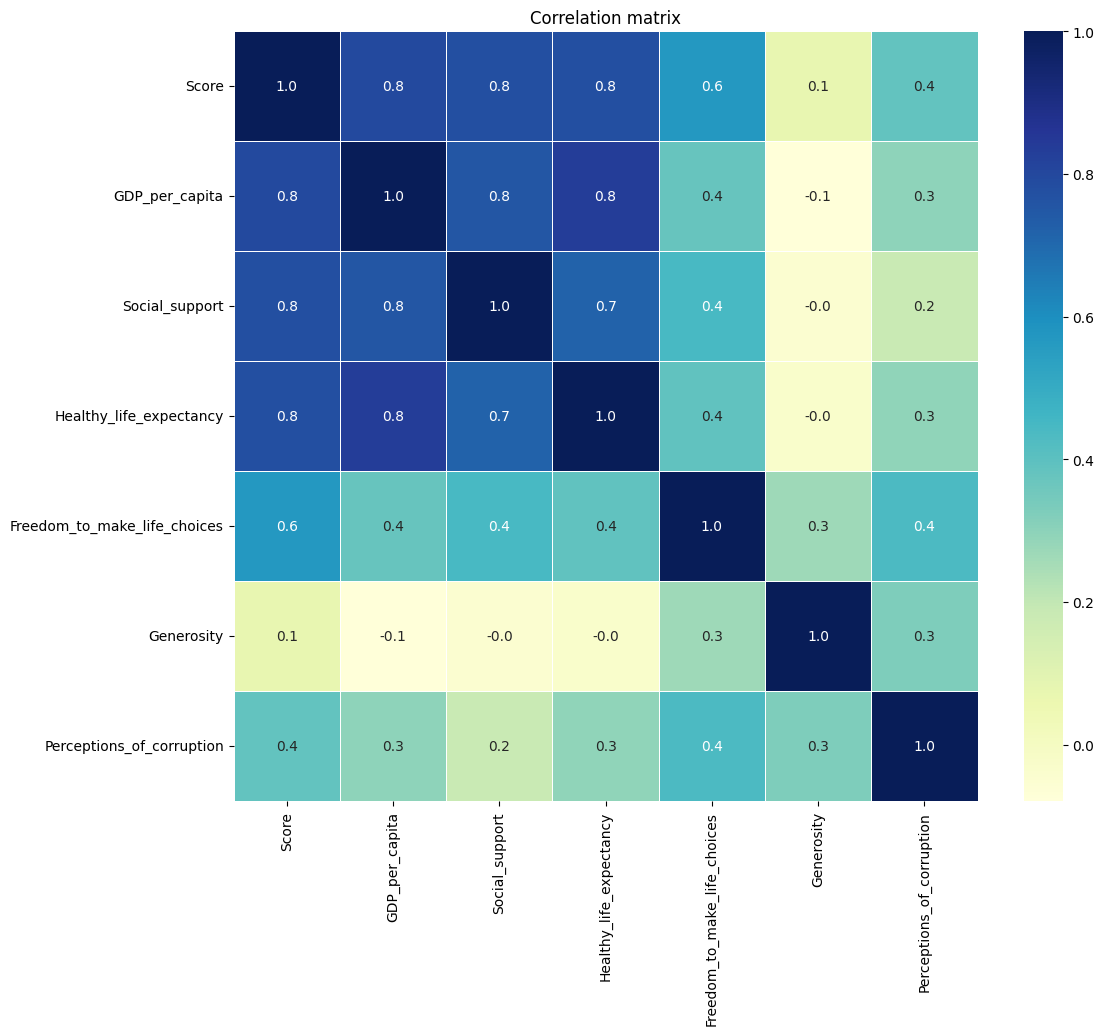

In [8]:
# Select the main numeric variables
vars_list = [
    "Score", "GDP_per_capita", "Social_support",
    "Healthy_life_expectancy", "Freedom_to_make_life_choices",
    "Generosity", "Perceptions_of_corruption"
]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[vars_list].corr(), annot=True, cmap="YlGnBu", linewidths=.5, fmt='.1f')
plt.title('Correlation matrix')
plt.show()

**Interpretation:**

- The Happiness Score is strongly correlated with GDP per capita, Social support and Healthy life expectancy.
- The Happiness Score is weakly correlated with Generosity.

So, as a first conclusion, the happiest countries tend to have higher GDP per capita, more social support and higher life expectancy.

## II) Linear regression

## A) Simple linear regression

A simple linear regression uses **one** explanatory variable to predict the outcome.

We use `statsmodels` formula API: `smf.ols("y ~ x", data)` fits the model $y = \beta_0 + \beta_1 x + u$.

Perform a linear regression to predict the Happiness Score using GDP per capita.

In [9]:
model_1 = smf.ols("Score ~ GDP_per_capita", df)
res_1 = model_1.fit()
res_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Score   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     262.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.32e-35
Time:                        15:37:53   Log-Likelihood:                -159.97
No. Observations:                 156   AIC:                             323.9
Df Residuals:                     154   BIC:                             330.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.3993      0.135     25.120      0.000       3.132       3.667
GDP_per_capita     2.2181      0.137     16.202      0.000       1.948       2.489
==============================================================================
Omnibus:                        1.139   Durbin-Watson:                   1.378
Prob(Omnibus):                  0.566   Jarque-Bera (JB):                1.244
Skew:                          -0.177   Prob(JB):                        0.537
Kurtosis:                       2.742   Cond. No.                         4.77
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**How to read the output:**
- **R-squared** tells us how much of the variation in Score is explained by GDP per capita. Higher is better (max = 1).
- The **coefficient** on GDP_per_capita tells us: for a one-unit increase in GDP per capita, the predicted Score changes by this amount.
- The **p-value** (column `P>|t|`) tells us if the coefficient is statistically significant. A value below 0.05 means it is significant.

We can visualize the regression line on top of the scatter plot using `sns.regplot()`.

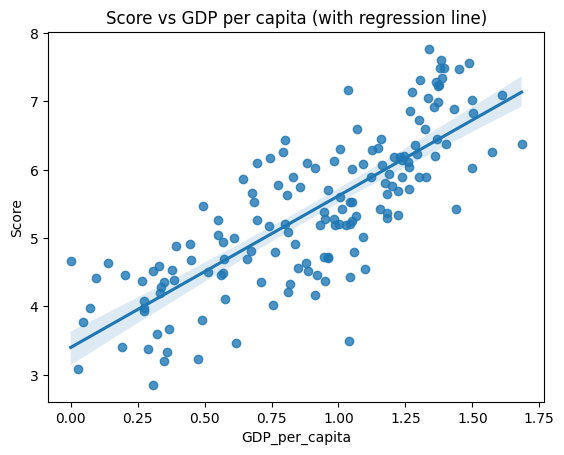

In [10]:
sns.regplot(x='GDP_per_capita', y='Score', data=df)
plt.title('Score vs GDP per capita (with regression line)')
plt.show()

Now try another simple regression using Healthy life expectancy.

In [11]:
model_2 = smf.ols("Score ~ Healthy_life_expectancy", df)
res_2 = model_2.fit()
res_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Score   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     239.1
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.79e-33
Time:                        15:37:56   Log-Likelihood:                -164.48
No. Observations:                 156   AIC:                             333.0
Df Residuals:                     154   BIC:                             339.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   2.8068      0.177     15.837      0.000       2.457       3.157
Healthy_life_expectancy     3.5854      0.232     15.462      0.000       3.127       4.043
==============================================================================
Omnibus:                        6.324   Durbin-Watson:                   1.140
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                3.543
Skew:                          -0.148   Prob(JB):                        0.170
Kurtosis:                       2.324   Cond. No.                         6.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

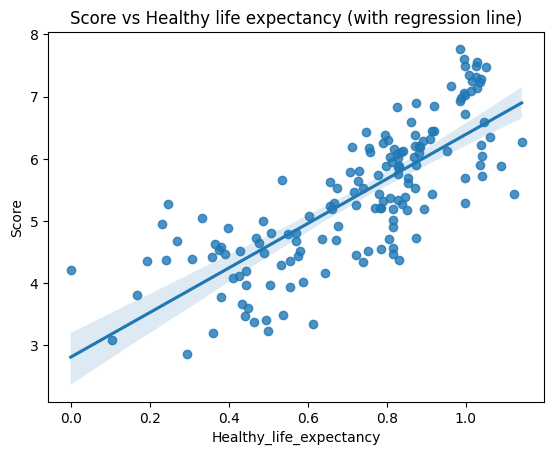

In [12]:
sns.regplot(x='Healthy_life_expectancy', y='Score', data=df)
plt.title('Score vs Healthy life expectancy (with regression line)')
plt.show()

## B) Multiple linear regression

A multiple linear regression uses **several** explanatory variables at the same time.

This lets us see the effect of each variable *while controlling for the others*.

Perform a multiple regression using several variables to predict the Happiness Score.

In [13]:
model_3 = smf.ols("Score ~ Healthy_life_expectancy + Freedom_to_make_life_choices + GDP_per_capita + Social_support", df)
res_3 = model_3.fit()
res_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Score   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     127.0
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           2.82e-47
Time:                        15:37:59   Log-Likelihood:                -122.62
No. Observations:                 156   AIC:                             255.2
Df Residuals:                     151   BIC:                             270.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        1.8921      0.199      9.491      0.000       1.498       2.286
Healthy_life_expectancy          1.1414      0.337      3.384      0.001       0.475       1.808
Freedom_to_make_life_choices     1.8458      0.340      5.423      0.000       1.173       2.518
GDP_per_capita                   0.8105      0.216      3.745      0.000       0.383       1.238
Social_support                   1.0166      0.235      4.331      0.000       0.553       1.480
==============================================================================
Omnibus:                        5.077   Durbin-Watson:                   1.641
Prob(Omnibus):                  0.079   Jarque-Bera (JB):                4.685
Skew:                          -0.413   Prob(JB):                       0.0961
Kurtosis:                       3.198   Cond. No.                         17.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Interpretation:**

- The **Adjusted R-squared** is higher than in the simple regressions. Adding more relevant variables improves the model.
- Compare the Adjusted R-squared across models to find which explains happiness best.
- Look at the p-values: are all variables statistically significant?

**Exercise:** By comparing Adjusted R-squared values, which regression explains happiness best?

In [14]:
print("Model 1 (GDP only) - Adj. R²:", round(res_1.rsquared_adj, 3))
print("Model 2 (Health only) - Adj. R²:", round(res_2.rsquared_adj, 3))
print("Model 3 (Multiple) - Adj. R²:", round(res_3.rsquared_adj, 3))

Model 1 (GDP only) - Adj. R²: 0.628
Model 2 (Health only) - Adj. R²: 0.606
Model 3 (Multiple) - Adj. R²: 0.765


The multiple regression has the highest Adjusted R-squared, meaning it explains the most variation in the happiness score.

### Polynomial Regression

Sometimes the relationship between two variables is **not a straight line**.  
A **polynomial regression** allows the relationship to be curved instead of linear.

Instead of estimating only a straight-line model:

$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

we allow higher powers of $x$:

$$
y = \beta_0 
+ \beta_1 x 
+ \beta_2 x^2 
+ \beta_3 x^3 
+ \dots 
+ \beta_n x^n 
+ \varepsilon
$$

where:

- $x$ = Happiness Score  
- $y$ = Healthy life expectancy  
- $n$ = degree of the polynomial  

Even though the curve looks nonlinear, the model is still estimated using **ordinary linear regression** — we simply add transformed versions of the same variable.

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

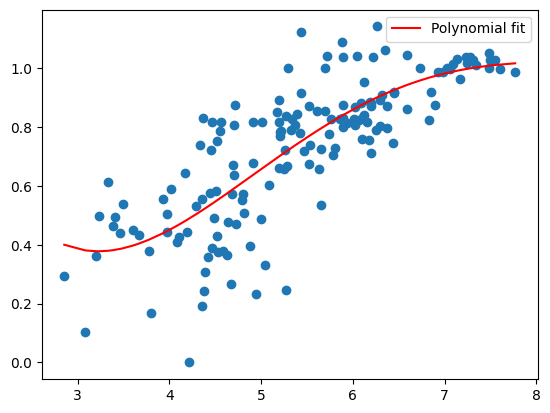

In [17]:
# Variables
x = df["Score"].values.reshape(-1, 1)
y = df["Healthy_life_expectancy"].values.reshape(-1, 1)

# Scatter plot
plt.plot(df["Score"], df["Healthy_life_expectancy"], 'o')

# Create polynomial features

polynomial_features = PolynomialFeatures(degree=4)
x_polynomial = polynomial_features.fit_transform(x)

# Fit regression model
polynomial_model = LinearRegression()
polynomial_model.fit(x_polynomial, y)

# Predicted values
y_predicted = polynomial_model.predict(x_polynomial)

# Plot fitted curve
plt.plot(x, y_predicted, color="red",label="Polynomial fit")

plt.legend()
plt.show()


In [18]:
# Linear regression
lin = LinearRegression().fit(x, y)
r2_linear = lin.score(x, y)

# Polynomial regression (degree 4)
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)

poly_model = LinearRegression().fit(x_poly, y)
r2_poly = poly_model.score(x_poly, y)

# Print 2 decimal places with f-strings  
print(f"Linear Regression R²: {r2_linear:.2f}")
print(f"Polynomial Regression R²: {r2_poly:.2f}")

Linear Regression R²: 0.61
Polynomial Regression R²: 0.62


The polynomial curve captures the slight non-linearity in the relationship. However, be cautious with high-degree polynomials — they can overfit the data.